# Which NWSL rosters are the oldest on the pitch?

A simple roster average age treats a 36-year-old third-string keeper the same as a starter who
plays every minute. This notebook instead asks: **averaged over the minutes a team has actually
played, how old is the team?**

Method:

1. Pull minutes played per player *per team* for a season from the ASA `player_xgoals` endpoint
   (with `split_by_teams=True` so a player traded mid-season counts for each club separately).
   This endpoint includes goalkeepers and players with zero shots, so it is a complete minutes ledger.
2. Pull birth dates from the ASA `players` endpoint.
3. For each team, compute the **minutes-weighted mean birth date**, i.e.
   $\bar{b}_{team} = \frac{\sum_i m_i\, b_i}{\sum_i m_i}$ where $m_i$ is minutes played and $b_i$ is the birth date.
4. Sort teams from oldest to youngest.

Data: [American Soccer Analysis](https://www.americansocceranalysis.com/) via `itscalledsoccer`.

In [1]:
from itscalledsoccer.client import AmericanSoccerAnalysis
from plotnine import *
import numpy as np
import pandas as pd

asa_client = AmericanSoccerAnalysis()
from sophso import decorate_team_ids, decorate_player_ids, nwsl_primary_colors, geom_image

In [2]:
LEAGUE = "nwsl"
SEASON = "2026"

## Minutes played by player and team

In [3]:
minutes_df = asa_client.get_player_xgoals(
    leagues=LEAGUE, season_name=SEASON, split_by_teams=True
)[["player_id", "team_id", "general_position", "minutes_played"]]

minutes_df = decorate_team_ids(minutes_df)

print(f"{len(minutes_df)} player-team rows, {minutes_df.player_id.nunique()} distinct players")
print(f"{minutes_df.player_id.duplicated().sum()} players appear for more than one team")
minutes_df.head()

406 player-team rows, 394 distinct players
12 players appear for more than one team


,player_id,team_id,general_position,minutes_played,team,team_logo
0,0Oq63DazQ6,odMX2OJqYL,FB,954,BOS,https://american-soccer-analysis-headshots.s3....
1,0Oq63DazQ6,raMyrr25d2,FB,629,NJY,https://american-soccer-analysis-headshots.s3....
2,0Oq63N8zQ6,zeQZeazqKw,W,127,NC,https://american-soccer-analysis-headshots.s3....
3,0Oq63NGdQ6,eV5D2w9QKn,CB,2449,UTA,https://american-soccer-analysis-headshots.s3....
4,0Oq63dogQ6,eV5D2w9QKn,W,793,UTA,https://american-soccer-analysis-headshots.s3....


## Birth dates

In [4]:
players_df = asa_client.get_players(leagues=LEAGUE)[["player_id", "player_name", "birth_date"]]
players_df["birth_date"] = pd.to_datetime(players_df.birth_date, errors="coerce")

df = minutes_df.merge(players_df, on="player_id", how="left")
assert len(df) == len(minutes_df), "merge changed row count; duplicate player_ids in players table?"
df.head()

,player_id,team_id,general_position,minutes_played,team,team_logo,player_name,birth_date
0,0Oq63DazQ6,odMX2OJqYL,FB,954,BOS,https://american-soccer-analysis-headshots.s3....,Lilly Reale,2003-08-12
1,0Oq63DazQ6,raMyrr25d2,FB,629,NJY,https://american-soccer-analysis-headshots.s3....,Lilly Reale,2003-08-12
2,0Oq63N8zQ6,zeQZeazqKw,W,127,NC,https://american-soccer-analysis-headshots.s3....,Ivy Garner,2003-05-07
3,0Oq63NGdQ6,eV5D2w9QKn,CB,2449,UTA,https://american-soccer-analysis-headshots.s3....,Kate Del Fava,1998-07-23
4,0Oq63dogQ6,eV5D2w9QKn,W,793,UTA,https://american-soccer-analysis-headshots.s3....,Paige Cronin,1996-11-13


### Coverage check

Not every player has a birth date in ASA's data. Before trusting the averages, check how many of
each team's minutes are played by someone we *can* date. Players without a birth date are dropped
from the weighted average (equivalent to assuming they are average-aged for their team).

In [5]:
df["has_birth_date"] = df.birth_date.notna()

coverage_df = (
    df.groupby("team")
    .apply(
        lambda g: pd.Series(
            {
                "minutes_total": g.minutes_played.sum(),
                "minutes_dated": g.loc[g.has_birth_date, "minutes_played"].sum(),
                "players_missing_birth_date": (~g.has_birth_date).sum(),
            }
        ),
        include_groups=False,
    )
    .assign(coverage=lambda d: d.minutes_dated / d.minutes_total)
    .sort_values("coverage")
)

coverage_df.style.format({"coverage": "{:.1%}", "minutes_total": "{:,.0f}", "minutes_dated": "{:,.0f}"})

,minutes_total,minutes_dated,players_missing_birth_date,coverage
team,,,,
BAY,"26,802","24,668",1,92.0%
LA,"26,945","25,838",2,95.9%
POR,"27,355","26,711",2,97.6%
NJY,"29,337","29,056",1,99.0%
UTA,"26,922","26,769",3,99.4%
LOU,"26,862","26,741",1,99.5%
HOU,"28,347","28,225",1,99.6%
ORL,"28,172","28,129",1,99.8%
KC,"29,243","29,243",0,100.0%


In [6]:
# The undated players with the most minutes, in case any are worth filling in by hand.
df.loc[~df.has_birth_date].sort_values("minutes_played", ascending=False).head(10)[
    ["player_name", "team", "general_position", "minutes_played"]
]

,player_name,team,general_position,minutes_played
21,Sydney Collins,BAY,FB,2134
280,Riley Tiernan,LA,W,1094
241,Renee Lyles,POR,W,453
187,Kayla Duran,NJY,FB,281
252,Jennie Immethun,POR,DM,191
136,Aria Nagai,UTA,DM,125
153,Caroline DeLisle,HOU,GK,122
282,Avery Ciorbu,LOU,DM,121
149,Sanne Lekven,ORL,W,43
5,Kalea Eichenberger,UTA,ST,14


## Minutes-weighted average birth date by team

To average dates, convert them to a number (days since the Unix epoch), take the weighted mean,
and convert back. A weighted mean *age* is the same thing expressed relative to a reference date;
here the reference date is the most recent game in the season so far.

In [7]:
games_df = asa_client.get_games(leagues=LEAGUE, season_name=SEASON)
games_df["date_time_utc"] = pd.to_datetime(games_df.date_time_utc)
as_of = games_df.loc[games_df.home_score.notna(), "date_time_utc"].max().normalize().tz_localize(None)
print(f"Ages computed as of {as_of.date()} (latest completed {SEASON} game)")

Ages computed as of 2026-09-20 (latest completed 2026 game)


In [8]:
DAYS_PER_YEAR = 365.25


def weighted_mean_birth_date(g):
    dated = g.loc[g.has_birth_date]
    days = (dated.birth_date - pd.Timestamp("1970-01-01")).dt.days.astype(float)
    weighted_days = np.average(days, weights=dated.minutes_played)
    return pd.Series(
        {
            "weighted_birth_date": pd.Timestamp("1970-01-01") + pd.Timedelta(days=weighted_days),
            "unweighted_birth_date": pd.Timestamp("1970-01-01") + pd.Timedelta(days=days.mean()),
            "players": len(dated),
            "minutes": dated.minutes_played.sum(),
        }
    )


team_age_df = (
    df.groupby(["team", "team_logo"])
    .apply(weighted_mean_birth_date, include_groups=False)
    .reset_index()
)

team_age_df["weighted_age"] = (as_of - team_age_df.weighted_birth_date).dt.days / DAYS_PER_YEAR
team_age_df["unweighted_age"] = (as_of - team_age_df.unweighted_birth_date).dt.days / DAYS_PER_YEAR
team_age_df["weighting_effect_years"] = team_age_df.weighted_age - team_age_df.unweighted_age

# Oldest team first: the earliest weighted birth date sorts to the top.
team_age_df = team_age_df.sort_values("weighted_birth_date", ignore_index=True)
team_age_df.index = team_age_df.index + 1
team_age_df.index.name = "rank"

(
    team_age_df[
        [
            "team",
            "weighted_birth_date",
            "weighted_age",
            "unweighted_age",
            "weighting_effect_years",
            "players",
            "minutes",
        ]
    ].style.format(
        {
            "weighted_birth_date": lambda d: d.strftime("%Y-%m-%d"),
            "weighted_age": "{:.2f}",
            "unweighted_age": "{:.2f}",
            "weighting_effect_years": "{:+.2f}",
            "minutes": "{:,.0f}",
        }
    )
)

,team,weighted_birth_date,weighted_age,unweighted_age,weighting_effect_years,players,minutes
rank,,,,,,,
1,NJY,1997-09-20,29.00,27.94,+1.05,28,"29,056"
2,UTA,1998-01-20,28.66,27.63,+1.03,23,"26,769"
3,DEN,1998-10-03,27.96,27.47,+0.50,21,"27,626"
4,KC,1998-11-16,27.84,26.98,+0.86,26,"29,243"
5,CHI,1998-12-29,27.72,27.45,+0.27,28,"26,994"
6,ORL,1999-01-21,27.66,27.29,+0.38,25,"28,129"
7,HOU,1999-11-08,26.86,27.68,-0.82,24,"28,225"
8,LOU,1999-11-19,26.83,25.85,+0.98,21,"26,741"
9,BOS,2000-02-10,26.61,25.89,+0.71,26,"28,323"


`weighting_effect_years` is the weighted age minus the plain roster average age. A positive value
means the team gives its minutes to older players than its roster average would suggest, a negative
value means the veterans are mostly on the bench.

## Plot

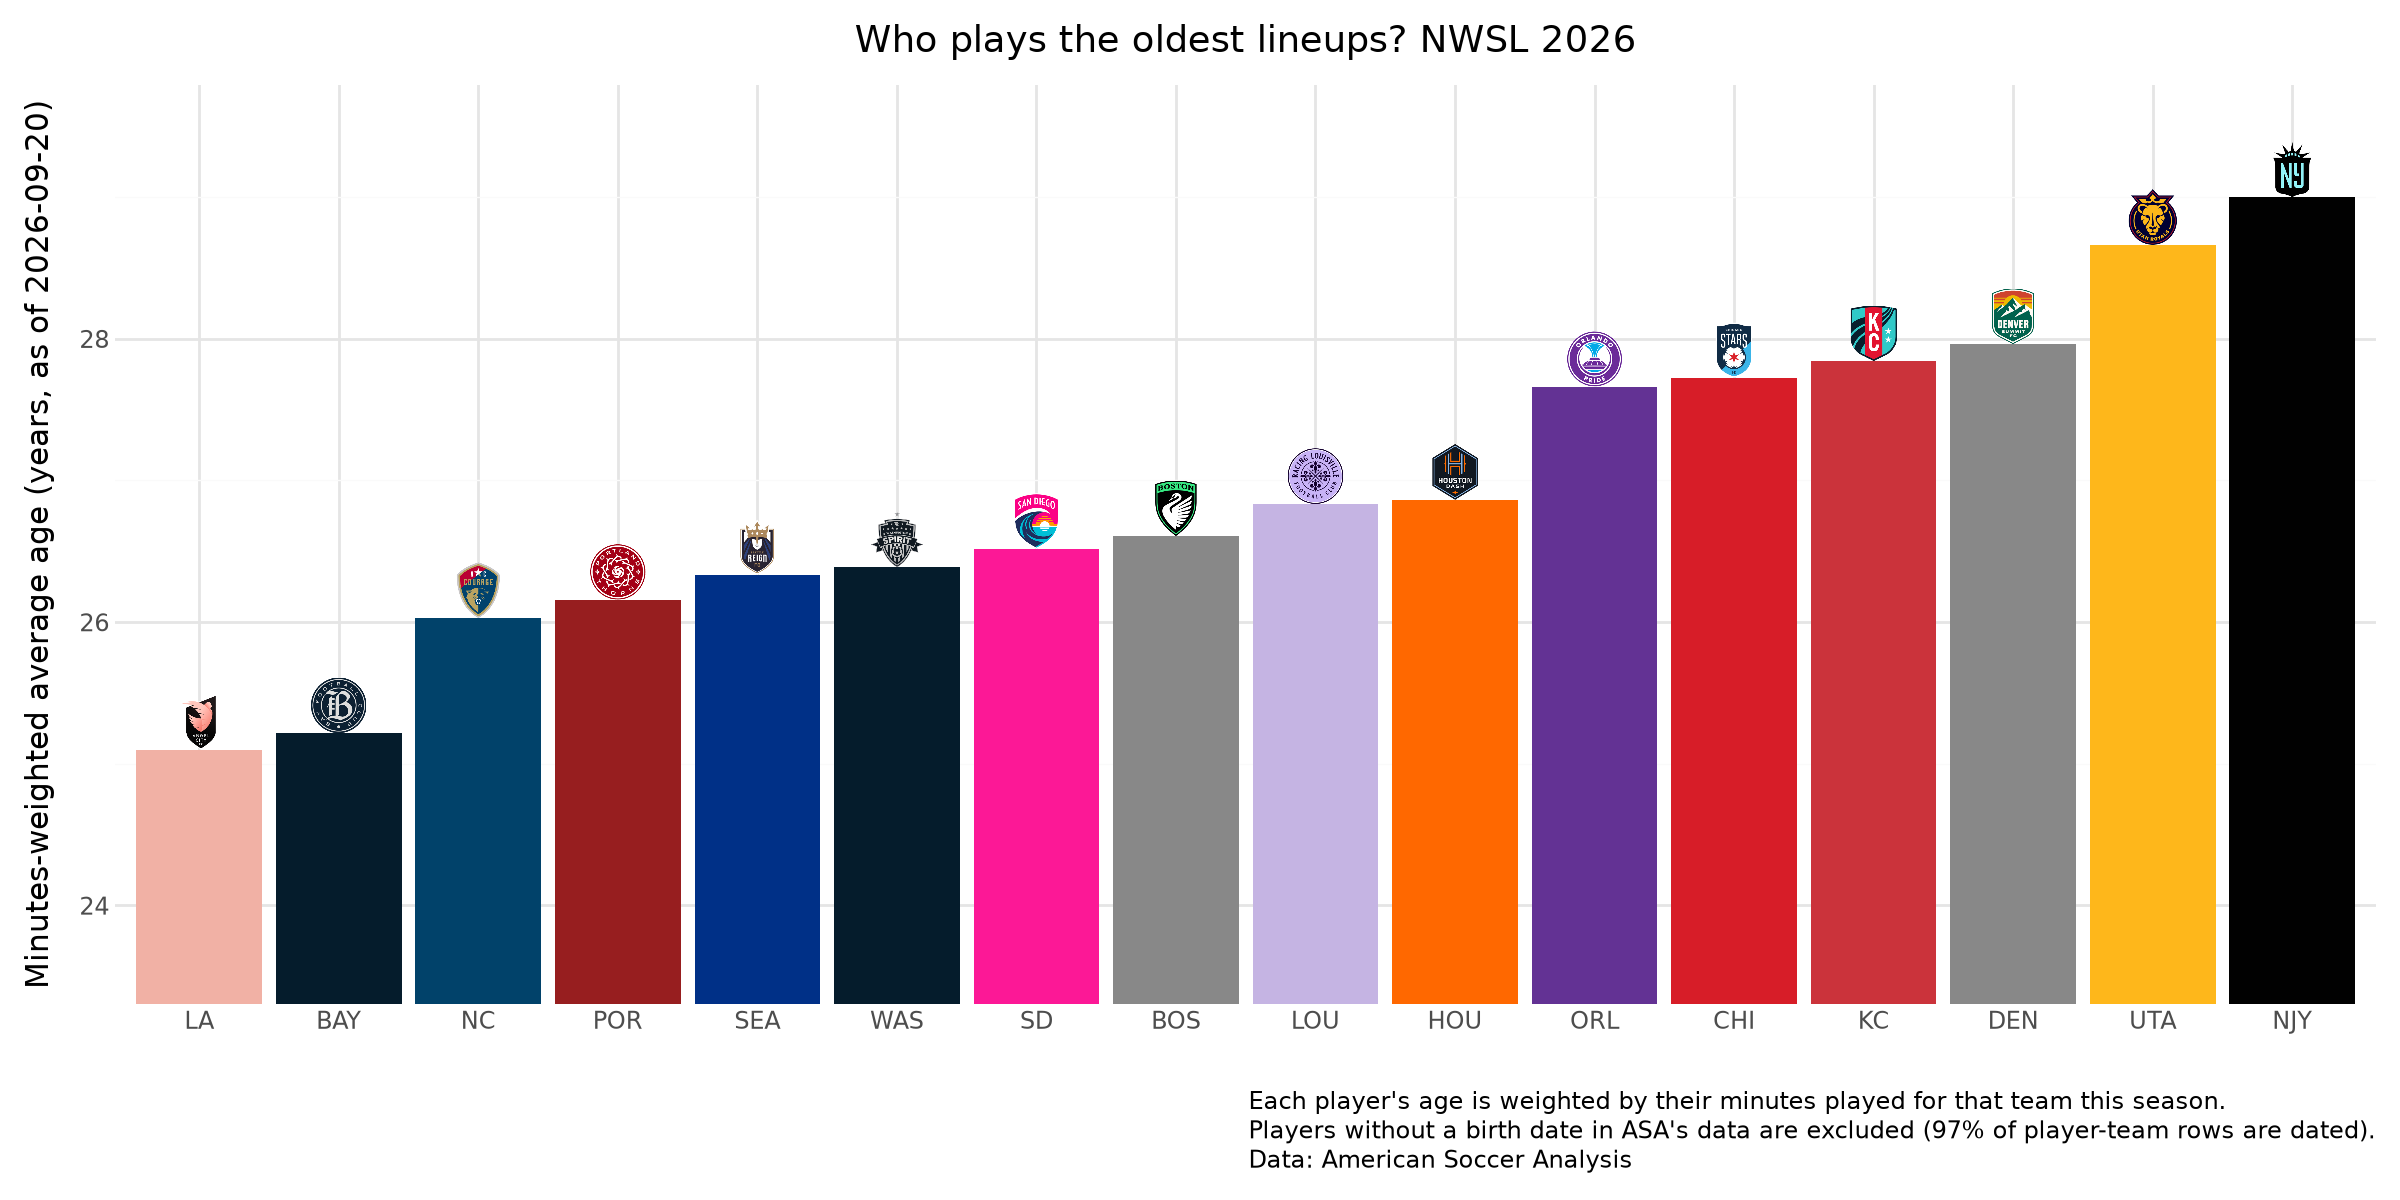

In [9]:
# Teams that are newer than the color map in sophso.py fall back to grey.
plot_colors = {t: nwsl_primary_colors.get(t, "#888888") for t in team_age_df.team}

# The default logo size is tuned for a 16-team horizontal bar chart; adjust if the figure size changes.
plot = (
    ggplot(team_age_df, aes(x="team", y="weighted_age", fill="team"))
    + geom_col()
    + scale_fill_manual(plot_colors, guide=None)
    + scale_x_discrete(limits=team_age_df.team[::-1])
    + geom_image(aes(image="team_logo"))
    + coord_cartesian(ylim=(team_age_df.weighted_age.min() - 1.5, team_age_df.weighted_age.max() + 0.5))
    + labs(
        x="",
        y=f"Minutes-weighted average age (years, as of {as_of.date()})",
        title=f"Who plays the oldest lineups? NWSL {SEASON}",
        caption=f"""
    Each player's age is weighted by their minutes played for that team this season.
    Players without a birth date in ASA's data are excluded ({df.has_birth_date.mean():.0%} of player-team rows are dated).
    Data: American Soccer Analysis""",
    )
    + theme_minimal()
    + theme(figure_size=(12, 6), axis_text_x=element_text(angle=0))
)
plot

## Who is driving each team's number?

For context, the five highest-minute players on the oldest and youngest teams.

In [10]:
def top_minutes(team, n=5):
    return (
        df.loc[(df.team == team) & df.has_birth_date]
        .assign(age=lambda d: (as_of - d.birth_date).dt.days / DAYS_PER_YEAR)
        .sort_values("minutes_played", ascending=False)
        .head(n)[["player_name", "general_position", "minutes_played", "age"]]
        .style.format({"age": "{:.1f}"})
        .set_caption(f"{team}: highest-minute players")
    )


oldest_team, youngest_team = team_age_df.team.iloc[0], team_age_df.team.iloc[-1]
top_minutes(oldest_team)

,player_name,general_position,minutes_played,age
295,Jaelin Howell,DM,2591,26.8
16,Jess Carter,CB,2430,28.9
114,Ann-Katrin Berger,GK,2357,35.9
48,Jaedyn Shaw,W,2193,21.8
249,Tierna Davidson,CB,2168,28.0


In [11]:
top_minutes(youngest_team)

,player_name,general_position,minutes_played,age
277,Angelina Anderson,GK,2455,25.5
160,Gisele Thompson,FB,2439,20.8
150,Emily Sams,CB,2422,27.2
154,Sarah Gorden,CB,2260,34.0
401,Ary Borges,DM,2087,26.7
